In [5]:
import os

folder_path = r"C:\Users\yuvas\Downloads\archive (3)"

print(os.listdir(folder_path))

['cardekho.csv']


In [6]:
import pandas as pd

file_path = r"C:\Users\yuvas\Downloads\archive (3)\cardekho.csv"

df = pd.read_csv(file_path)

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [7]:
df.shape

(8128, 12)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


In [9]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1202)

In [11]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (6926, 12)


In [12]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    208
engine                208
max_power             205
seats                 208
dtype: int64

In [13]:
numeric_cols = [
    "mileage(km/ltr/kg)",
    "engine",
    "seats"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print(df[numeric_cols].isnull().sum())

mileage(km/ltr/kg)    0
engine                0
seats                 0
dtype: int64


In [14]:
df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")

print(df["max_power"].dtype)
print("Missing max_power:", df["max_power"].isnull().sum())

float64
Missing max_power: 206


In [15]:
df["max_power"] = df["max_power"].fillna(df["max_power"].median())

print("Missing max_power:", df["max_power"].isnull().sum())

Missing max_power: 0


In [16]:
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [17]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.464550,1425.398787,87.551527,5.421600
std,4.078286,5.197670e+05,5.835810e+04,3.987878,487.026967,31.311523,0.972171
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.440000,1248.000000,81.830000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.320000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


In [18]:
print("Fuel types:")
print(df["fuel"].unique())

print("\nSeller types:")
print(df["seller_type"].unique())

print("\nTransmission types:")
print(df["transmission"].unique())

print("\nOwner types:")
print(df["owner"].unique())

Fuel types:
<StringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

Seller types:
<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

Transmission types:
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

Owner types:
<StringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str


In [19]:
print(df["owner"].unique())

<StringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str


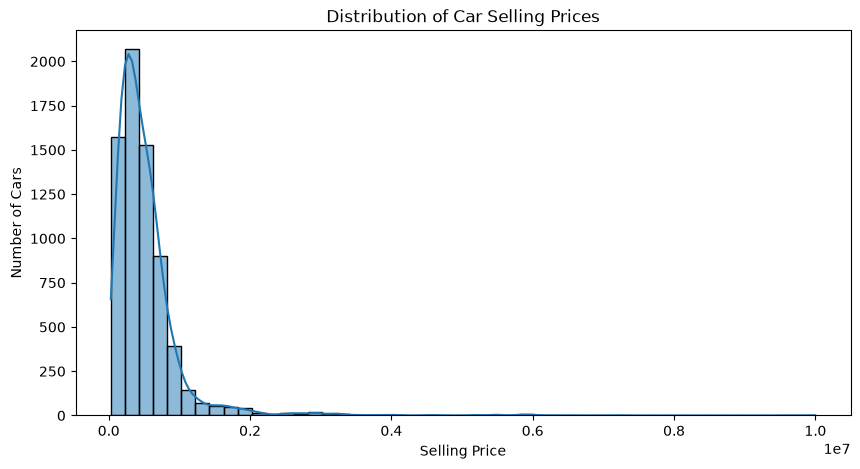

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df["selling_price"], bins=50, kde=True)
plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

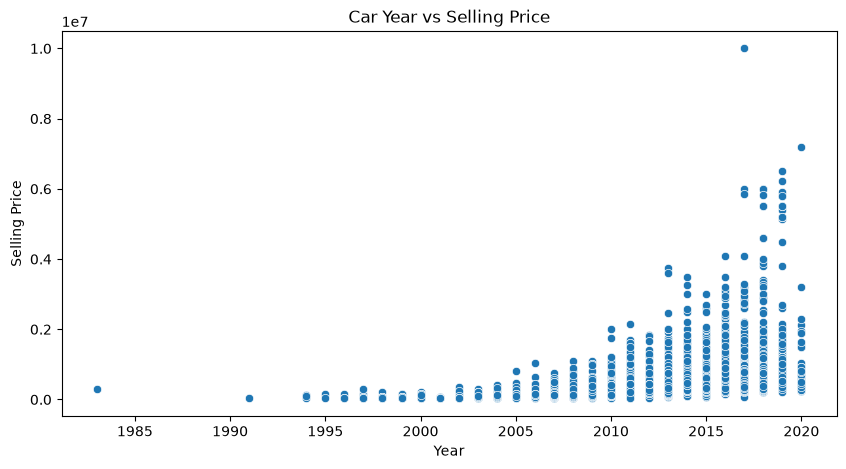

In [21]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="year",
    y="selling_price"
)

plt.title("Car Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()

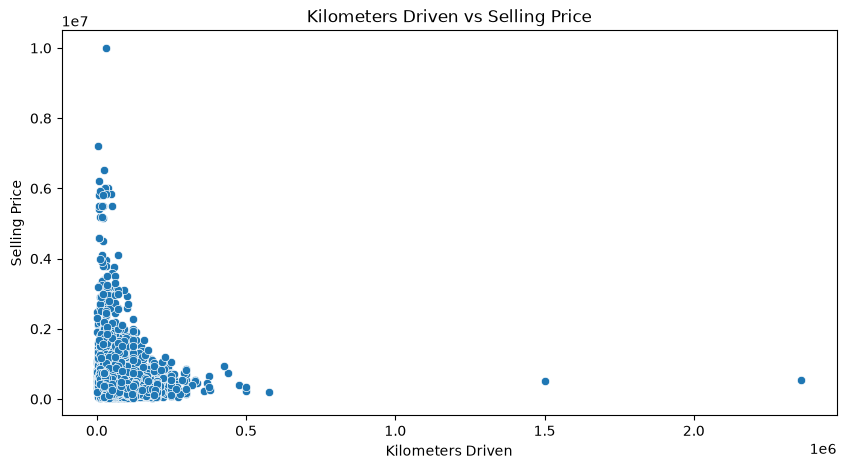

In [23]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

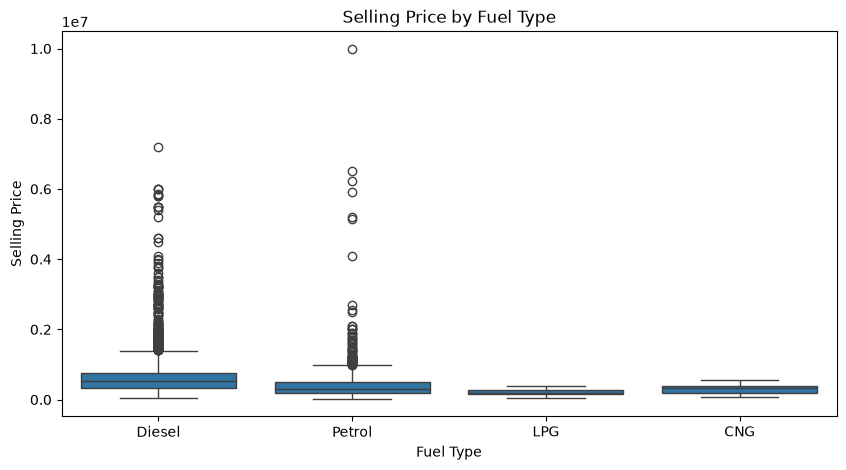

In [24]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

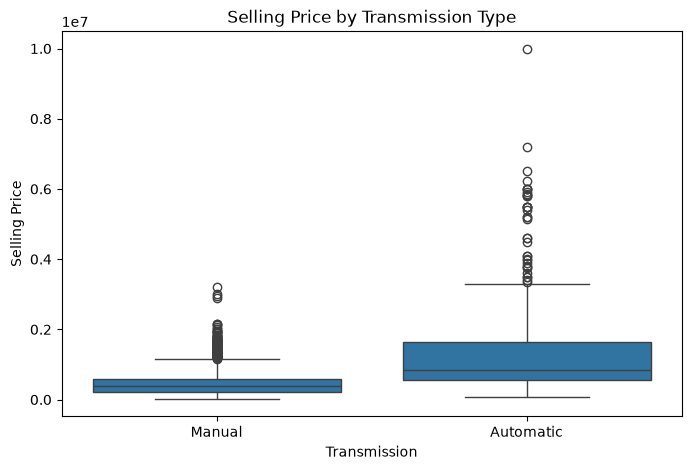

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="transmission",
    y="selling_price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

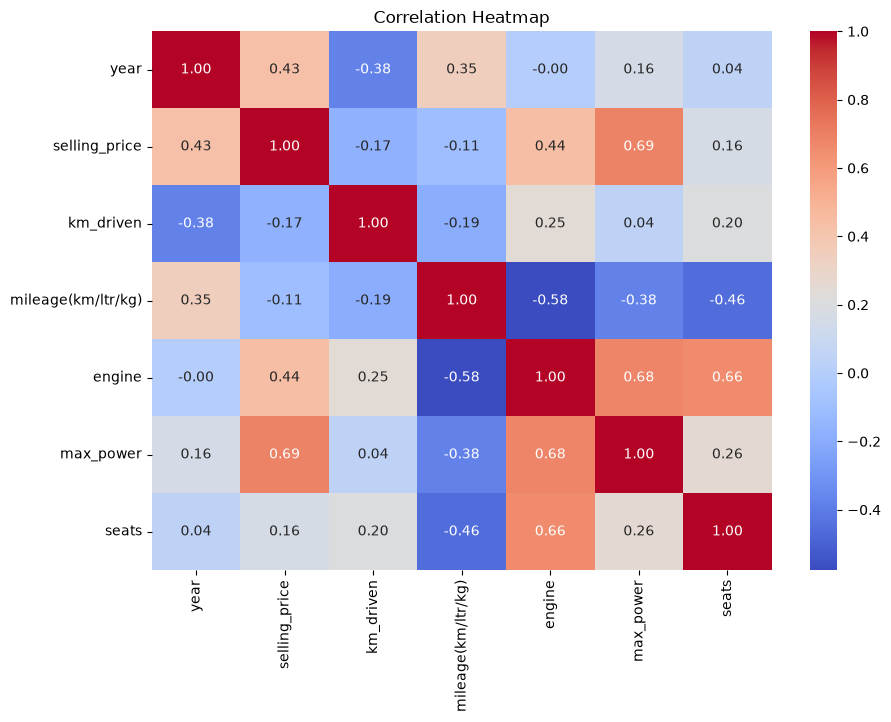

In [26]:
plt.figure(figsize=(10, 7))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [27]:
df = df.drop("name", axis=1)

df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [28]:
categorical_cols = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df.head()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,23.40,1248.0,74.00,5.0,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,21.14,1498.0,103.52,5.0,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,17.70,1497.0,78.00,5.0,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,23.00,1396.0,90.00,5.0,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,16.10,1298.0,88.20,5.0,False,False,True,True,False,True,False,False,False,False


In [29]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6926, 16)
Target shape: (6926,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5540, 16)
Testing features: (1386, 16)
Training target: (5540,)
Testing target: (1386,)


In [31]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [32]:
y_pred_linear = linear_model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred_linear[:10])

First 10 predicted prices:
[ 389966.4777917  1224993.14619523  777858.57962632  -17490.00960322
  832728.47533433  846549.75878589  356187.63334292   85891.02250636
  236939.4997551   557777.32372455]


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
MAE : 172654.80504492988
RMSE: 306982.06076314684
R²  : 0.5703205995074379


In [34]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [35]:
y_pred_tree = tree_model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred_tree[:10])

First 10 predicted prices:
[409999. 944999. 800000. 250000. 675000. 950000. 320000. 270000. 225000.
 520000.]


In [36]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("MAE :", mae_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree Results
MAE : 92742.74795574795
RMSE: 169335.31437376933
R²  : 0.8692584540946849


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [38]:
y_pred_rf = rf_model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred_rf[:10])

First 10 predicted prices:
[ 617559.96       1070476.43666667  831626.66666667  135376.34
  688820.          932889.99        292150.15666667  225566.60666667
  236186.65666667  529949.97      ]


In [39]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
MAE : 75058.15660377586
RMSE: 132065.27530680512
R²  : 0.9204764386367412


In [40]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_tree,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,172654.805045,306982.060763,0.570321
1,Decision Tree,92742.747956,169335.314374,0.869258
2,Random Forest,75058.156604,132065.275307,0.920476


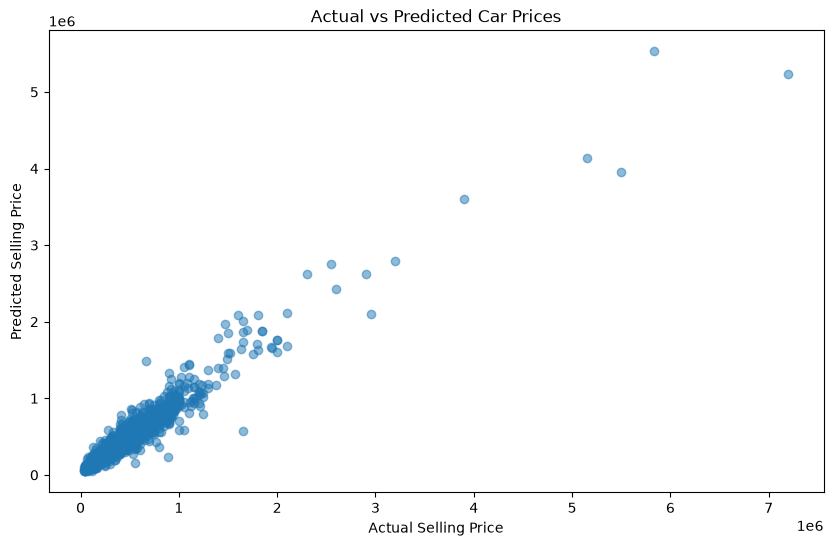

In [41]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [42]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,max_power,0.607025
0,year,0.232177
2,mileage(km/ltr/kg),0.049792
1,km_driven,0.049323
3,engine,0.029861
5,seats,0.009637
11,transmission_Manual,0.008109
13,owner_Second Owner,0.003137
6,fuel_Diesel,0.003103
9,seller_type_Individual,0.003077


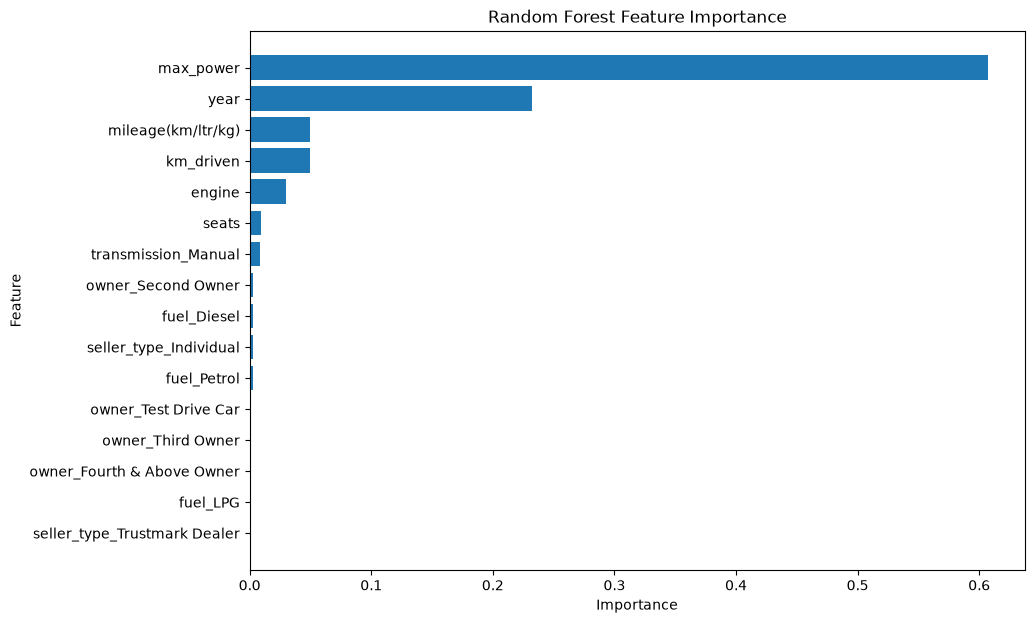

In [43]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [44]:
sample_car = X_test.iloc[[0]]

predicted_price = rf_model.predict(sample_car)[0]
actual_price = y_test.iloc[0]

print("Predicted Selling Price:", round(predicted_price, 2))
print("Actual Selling Price:", actual_price)

Predicted Selling Price: 617559.96
Actual Selling Price: 550000


## Conclusion

In this project, a machine learning model was developed to predict used car selling prices using the CarDekho dataset.

The dataset was cleaned by removing duplicate records, handling missing values, converting `max_power` into a numerical feature, and encoding categorical variables.

Three regression models were evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The Random Forest model achieved an R² score of approximately 0.92, with an MAE of approximately ₹75,058 and an RMSE of approximately ₹1,32,065 on the test dataset.

Feature importance analysis showed that `max_power` and `year` were among the most influential features for predicting car selling prices.

Overall, the project demonstrates how machine learning regression techniques can be applied to estimate used car prices based on vehicle characteristics.